In [3]:
import pandas as pd
from pathlib import Path

In [4]:
base_dir = Path('..') / 'data' / 'capture24'
print('Dossier', base_dir)
files = sorted(base_dir.glob('P*.csv.gz'))
print('Nombre de fichiers P*.csv.gz trouvés :', len(files))
files[:5]

Dossier ../data/capture24
Nombre de fichiers P*.csv.gz trouvés : 151


[PosixPath('../data/capture24/P001.csv.gz'),
 PosixPath('../data/capture24/P002.csv.gz'),
 PosixPath('../data/capture24/P003.csv.gz'),
 PosixPath('../data/capture24/P004.csv.gz'),
 PosixPath('../data/capture24/P005.csv.gz')]

In [5]:
batch_size = 50

#for start in range(0, len(files), batch_size):
start = 0
end = 20
#end = start + batch_size
batch_files = files[start:end]
dfs = []
for f in batch_files:
    print(f)
    df_tmp = pd.read_csv(f, compression='gzip')
    df_tmp['source_file'] = f.name
    dfs.append(df_tmp)

df_batch = pd.concat(dfs, ignore_index=True)

print(df_batch.columns)
del dfs

../data/capture24/P001.csv.gz


/tmp/ipykernel_2396581/2883607728.py:11: DtypeWarning: Columns (0: annotation) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp = pd.read_csv(f, compression='gzip')


../data/capture24/P002.csv.gz
../data/capture24/P003.csv.gz
../data/capture24/P004.csv.gz
../data/capture24/P005.csv.gz
../data/capture24/P006.csv.gz
../data/capture24/P007.csv.gz
../data/capture24/P008.csv.gz
../data/capture24/P009.csv.gz
../data/capture24/P010.csv.gz
../data/capture24/P011.csv.gz
../data/capture24/P012.csv.gz
../data/capture24/P013.csv.gz
../data/capture24/P014.csv.gz
../data/capture24/P015.csv.gz
../data/capture24/P016.csv.gz
../data/capture24/P017.csv.gz
../data/capture24/P018.csv.gz
../data/capture24/P019.csv.gz
../data/capture24/P020.csv.gz
Index(['time', 'x', 'y', 'z', 'annotation', 'source_file'], dtype='str')


In [6]:
import pandas as pd

meta = pd.read_csv(base_dir / "metadata.csv").head(52)

df_batch["pid"] = df_batch["source_file"].str.replace(".csv.gz", "", regex=False)

df_batch = df_batch.merge(meta, on="pid", how="left")

In [7]:
print(df_batch.columns)

Index(['time', 'x', 'y', 'z', 'annotation', 'source_file', 'pid', 'age',
       'sex'],
      dtype='str')


In [8]:
df = df_batch.drop(columns=['source_file'])

In [9]:
del df_batch

In [10]:
df.shape

(185810842, 8)

In [11]:
dict_df = pd.read_csv(base_dir / "annotation-label-dictionary.csv")

In [12]:
df = df.merge(
    dict_df[["annotation", "label:Walmsley2020", "label:WillettsSpecific2018"]],
    on="annotation",
    how="left"
)

In [13]:
df = df.drop(columns=['annotation'])
df.head()

,time,x,y,z,pid,age,sex,label:Walmsley2020,label:WillettsSpecific2018
0,2016-11-13 02:18:00.000000,-0.46669,-0.533341,0.658472,P001,38-52,F,sleep,sleep
1,2016-11-13 02:18:00.010000,-0.46669,-0.533341,0.658472,P001,38-52,F,sleep,sleep
2,2016-11-13 02:18:00.020000,-0.46669,-0.533341,0.658472,P001,38-52,F,sleep,sleep
3,2016-11-13 02:18:00.030000,-0.46669,-0.533341,0.658472,P001,38-52,F,sleep,sleep
4,2016-11-13 02:18:00.040000,-0.46669,-0.533341,0.658472,P001,38-52,F,sleep,sleep


In [14]:
import numpy as np

df['magnitude'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)  

In [15]:
from scipy.signal import butter, filtfilt

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

fs = 100
cutoff_noise = 20.0
cutoff_gravity = 0.3

for axis in ['x', 'y', 'z']:
    raw = df[axis].values

    # 1. suppression bruit
    clean = butter_lowpass_filter(raw, cutoff_noise, fs)

    # 2. estimation gravité
    gravity = butter_lowpass_filter(clean, cutoff_gravity, fs)

    # 3. signal corps (accélération dynamique)
    body = clean - gravity

    df[f'{axis}_filtered'] = body

In [16]:
df['magnitude_filtered'] = np.sqrt(df['x_filtered']**2 + df['y_filtered']**2 + df['z_filtered']**2)  

In [17]:
df['label:WillettsSpecific2018'].unique()

<StringArray>
[           'sleep',                nan, 'household-chores',
          'walking',          'vehicle',         'standing',
   'mixed-activity',          'sitting',        'bicycling',
           'sports',      'manual-work']
Length: 11, dtype: str

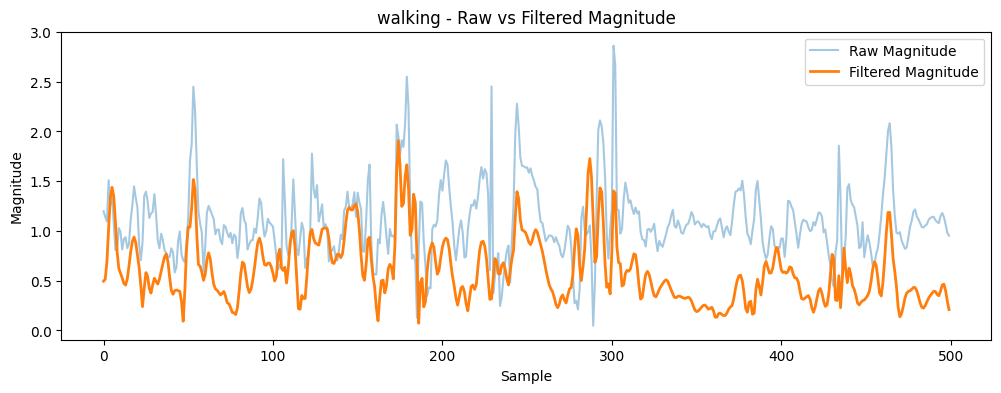

In [18]:
import matplotlib.pyplot as plt

activity = "walking"

df_sample = df[df["label:WillettsSpecific2018"] == activity].sort_values("time").head(500)

plt.figure(figsize=(12, 4))

plt.plot(
    df_sample["magnitude"].values,
    label="Raw Magnitude",
    alpha=0.4
)

plt.plot(
    df_sample["magnitude_filtered"].values,
    label="Filtered Magnitude",
    linewidth=2
)

plt.title(f"{activity} - Raw vs Filtered Magnitude")
plt.xlabel("Sample")
plt.ylabel("Magnitude")
plt.legend()
plt.show()

In [19]:
window_size = 5 * fs # 5 secondes = 500 samples 
step_size = window_size // 2 # overlap 50% 

df = df.sort_values(["pid", "time"])

X = []
y = []
y2 = []
pids = []

features = [
    "x", "y", "z",
    "x_filtered", "y_filtered", "z_filtered",
    "magnitude", "magnitude_filtered"
]

for pid, group in df.groupby("pid"):
    data = group[features].values
    labels = group["label:Walmsley2020"].values
    labels2 = group["label:WillettsSpecific2018"].values

    for start in range(0, len(data) - window_size, step_size):
        end = start + window_size
        window_labels = labels[start:end]
        window_labels2 = labels2[start:end]

        if len(window_labels) == 0 or len(window_labels2) == 0:
            continue

        label = pd.Series(window_labels).dropna().mode()
        label2 = pd.Series(window_labels2).dropna().mode()

        if len(label) == 0 or len(label2) == 0:
            continue

        X.append(data[start:end])
        y.append(label[0])
        y2.append(label2[0])
        pids.append(pid)

X = np.array(X)
y = np.array(y)
y2 = np.array(y2)
pids = np.array(pids)

In [20]:
def extract_features(window):
    feats = []
    for i in range(window.shape[1]):
        col = window[:, i]
        feats.extend([
            col.mean(), col.std(), col.min(), col.max(),
            np.median(col), np.percentile(col, 25), np.percentile(col, 75)
        ])
    return feats

X_feat = np.array([extract_features(w) for w in X])
print(X_feat.shape)

(493354, 56)


In [21]:
from sklearn.preprocessing import LabelEncoder

le1 = LabelEncoder()
le2 = LabelEncoder()

y_enc = le1.fit_transform(y)
y2_enc = le2.fit_transform(y2)

print("Walmsley classes:", le1.classes_)
print("Willetts classes:", le2.classes_)



Walmsley classes: ['light' 'moderate-vigorous' 'sedentary' 'sleep']
Willetts classes: ['bicycling' 'household-chores' 'manual-work' 'mixed-activity' 'sitting'
 'sleep' 'sports' 'standing' 'vehicle' 'walking']


In [22]:
X_feat

array([[-0.46816084,  0.00456521, -0.4823338 , ...,  0.00421024,
         0.0029096 ,  0.00618855],
       [-0.46934974,  0.00587619, -0.4823338 , ...,  0.00432099,
         0.0029017 ,  0.00720293],
       [-0.47006934,  0.0064375 , -0.4823338 , ...,  0.00573487,
         0.00379671,  0.00745844],
       ...,
       [-0.13514687,  0.00736394, -0.14038524, ...,  0.00535952,
         0.00332742,  0.00804336],
       [-0.13595757,  0.00703028, -0.14038524, ...,  0.00397164,
         0.00251815,  0.00552721],
       [-0.13464798,  0.00751864, -0.14038524, ...,  0.00428708,
         0.00253864,  0.00624669]])

In [23]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_feat, y_enc, groups=pids))

X_train, X_test = X_feat[train_idx], X_feat[test_idx]
y_train, y_test = y_enc[train_idx], y_enc[test_idx]
y2_train, y2_test = y2_enc[train_idx], y2_enc[test_idx]

# vérifie qu'aucun participant n'est dans les deux sets
print("Train pids:", len(set(pids[train_idx])))
print("Test pids:", len(set(pids[test_idx])))
print("Overlap:", set(pids[train_idx]) & set(pids[test_idx]))  # doit être vide

Train pids: 16
Test pids: 4
Overlap: set()


In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42, class_weight="balanced"),
#    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
#    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced")),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    results.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1
    })
    print(f"{name}: acc={acc:.3f}, f1_macro={f1:.3f}")
    print(classification_report(y_test, y_pred))
    print('\n')

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df

LogisticRegression: acc=0.656, f1_macro=0.600
              precision    recall  f1-score   support

           0       0.49      0.49      0.49     16499
           1       0.40      0.66      0.50      6372
           2       0.75      0.48      0.58     38051
           3       0.74      0.95      0.83     31588

    accuracy                           0.66     92510
   macro avg       0.59      0.65      0.60     92510
weighted avg       0.67      0.66      0.65     92510



DecisionTree: acc=0.518, f1_macro=0.449
              precision    recall  f1-score   support

           0       0.33      0.58      0.42     16499
           1       0.21      0.15      0.18      6372
           2       0.51      0.50      0.50     38051
           3       0.86      0.59      0.70     31588

    accuracy                           0.52     92510
   macro avg       0.48      0.45      0.45     92510
weighted avg       0.57      0.52      0.53     92510



RandomForest: acc=0.626, f1_macro=0.537


,model,accuracy,f1_macro
0,LogisticRegression,0.655767,0.600016
2,RandomForest,0.626030,0.537104
1,DecisionTree,0.518452,0.449070
3,KNN,0.485050,0.424064


In [25]:
results2 = []

models = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42, class_weight="balanced"),
#    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
#    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced")),
}

for name, model in models.items():
    model.fit(X_train, y2_train)
    
    y2_pred = model.predict(X_test)

    acc = accuracy_score(y2_test, y2_pred)
    f1 = f1_score(y2_test, y2_pred, average="macro")

    results2.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1,
    })
    
    print(f"{name}: acc={acc:.3f}, f1_macro={f1:.3f}")
    print(classification_report(y2_test, y2_pred))
    print('\n')

/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/60

LogisticRegression: acc=0.500, f1_macro=0.302
              precision    recall  f1-score   support

           0       0.38      0.83      0.52       939
           1       0.25      0.33      0.28      3823
           2       0.00      0.00      0.00         0
           3       0.34      0.19      0.25      7643
           4       0.71      0.25      0.38     34960
           5       0.77      0.93      0.84     31588
           6       0.00      0.00      0.00         0
           7       0.05      0.17      0.08      4230
           8       0.29      0.58      0.39      3091
           9       0.27      0.29      0.28      6236

    accuracy                           0.50     92510
   macro avg       0.31      0.36      0.30     92510
weighted avg       0.60      0.50      0.50     92510



DecisionTree: acc=0.422, f1_macro=0.247
              precision    recall  f1-score   support

           0       0.39      0.49      0.43       939
           1       0.10      0.31      0.16 

/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

RandomForest: acc=0.574, f1_macro=0.348
              precision    recall  f1-score   support

           0       0.96      0.72      0.83       939
           1       0.24      0.48      0.32      3823
           2       0.00      0.00      0.00         0
           3       0.40      0.02      0.05      7643
           4       0.58      0.81      0.68     34960
           5       0.94      0.56      0.70     31588
           6       0.00      0.00      0.00         0
           7       0.02      0.01      0.01      4230
           8       0.57      0.57      0.57      3091
           9       0.26      0.43      0.33      6236

    accuracy                           0.57     92510
   macro avg       0.40      0.36      0.35     92510
weighted avg       0.63      0.57      0.56     92510





/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

KNN: acc=0.407, f1_macro=0.273
              precision    recall  f1-score   support

           0       0.42      0.80      0.55       939
           1       0.14      0.47      0.22      3823
           2       0.00      0.00      0.00         0
           3       0.29      0.09      0.14      7643
           4       0.47      0.53      0.50     34960
           5       0.83      0.37      0.51     31588
           6       0.00      0.00      0.00         0
           7       0.05      0.05      0.05      4230
           8       0.43      0.63      0.51      3091
           9       0.19      0.30      0.24      6236

    accuracy                           0.41     92510
   macro avg       0.28      0.32      0.27     92510
weighted avg       0.53      0.41      0.43     92510





/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/lustre09/project/6081099/haninih/HAR_models/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag